# Objective 4 — Counterfactual Explanations (DiCE)

Loads the locked 99.12% model and generates DiCE counterfactuals.

## Setup — install dependencies

In [1]:
!pip -q install scikit-learn xgboost imbalanced-learn tensorflow scipy shap lime dice-ml anthropic matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 29.6 MB/s eta 0:00:00


## Load the locked 99.12% model

In [2]:
# ===== LOAD the locked 99.12% model (run this FIRST) =====
# Requires the saved model folder in Google Drive: MyDrive/TrustBreast_locked/
# (produced once by File 1 - Objective 1). No retraining here, so the number is always 99.12%.
import os, pickle, joblib, numpy as np, tensorflow as tf
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
SAVE_DIR = '/content/drive/MyDrive/TrustBreast_locked'
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception:
    SAVE_DIR = '/content/TrustBreast_locked'
rf_model  = joblib.load(SAVE_DIR + '/rf_model.pkl')
xgb_model = joblib.load(SAVE_DIR + '/xgb_model.pkl')
scaler    = joblib.load(SAVE_DIR + '/scaler.pkl')
dnn_best  = tf.keras.models.load_model(SAVE_DIR + '/dnn_best.keras')
dnn_model = tf.keras.models.load_model(SAVE_DIR + '/dnn_model.keras')
with open(SAVE_DIR + '/state.pkl','rb') as f: state = pickle.load(f)
globals().update({k:v for k,v in state.items() if v is not None})
if globals().get('prob_ensemble_val') is None and 'X_val_sc' in globals():
    _rf=rf_model.predict_proba(X_val_sc)[:,1]; _xg=xgb_model.predict_proba(X_val_sc)[:,1]
    _dn=dnn_best.predict(X_val_sc, verbose=0).ravel(); prob_ensemble_val=(_rf+_xg+_dn)/3
model_dnn=dnn_best; rf_aug=rf_model; xgb_aug=xgb_model; feature_names=list(X.columns)
print('LOADED locked model. Ensemble accuracy:', round(accuracy_score(y_test, ens_pred)*100,2), 'percent')

Mounted at /content/drive
LOADED locked model. Ensemble accuracy: 99.12 percent


### Bridge — expose model aliases

In [3]:
# --- aliases so O2/O3/O4 cells find the trained models ---
model_dnn = dnn_best        # O3 (MC Dropout) expects this name
rf_aug    = rf_model        # O4 (DiCE) expects this name
xgb_aug   = xgb_model       # O4 (DiCE) expects this name
feature_names = list(X.columns)
print('Bridge ready. Ensemble threshold from O1:', best_ens_thr)

Bridge ready. Ensemble threshold from O1: 0.42000000000000015


**OBJECTIVE 4**

In [4]:
!pip install dice-ml --quiet

In [5]:
import dice_ml
import importlib.metadata

print("✅ DiCE installed successfully!")
try:
    print(f"DiCE version: {importlib.metadata.version('dice-ml')}")
except importlib.metadata.PackageNotFoundError:
    print("DiCE version: Not found (package might be installed under a different name or in a non-standard way)")

✅ DiCE installed successfully!
DiCE version: 0.12


In [6]:
import dice_ml
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Data load (as in previous complete refresh cells)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
col_names = ['id','diagnosis',
  'radius_mean','texture_mean','perimeter_mean','area_mean',
  'smoothness_mean','compactness_mean','concavity_mean',
  'concave_points_mean','symmetry_mean','fractal_dimension_mean',
  'radius_se','texture_se','perimeter_se','area_se',
  'smoothness_se','compactness_se','concavity_se',
  'concave_points_se','symmetry_se','fractal_dimension_se',
  'radius_worst','texture_worst','perimeter_worst','area_worst',
  'smoothness_worst','compactness_worst','concavity_worst',
  'concave_points_worst','symmetry_worst','fractal_dimension_worst']

df = pd.read_csv(url, header=None, names=col_names)

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df.drop(['id','diagnosis'], axis=1)
y = df['diagnosis']

# Define feature_names
feature_names = X.columns.tolist()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================
# STEP 4.2 — CREATE DiCE DATA OBJECT
# ============================================

# Apna training data ek DataFrame mein combine karo (features + target)
df_train_dice = pd.DataFrame(X_train, columns=feature_names)  # feature_names = WBCD ke 30 column names
df_train_dice['diagnosis'] = y_train  # target column add karo (0=Benign, 1=Malignant)

print(f"DiCE training data shape: {df_train_dice.shape}")
print(df_train_dice.head())

# Continuous features list (WBCD ke saare 30 features continuous hain)
continuous_features = feature_names  # sab numeric measurements hain (radius, texture, etc.)

# DiCE Data object banao
d = dice_ml.Data(
    dataframe=df_train_dice,
    continuous_features=continuous_features,
    outcome_name='diagnosis'
)

print("\n✅ DiCE Data object created successfully!")
print(f"   Total features: {len(continuous_features)}")
print(f"   Outcome column: 'diagnosis'")

DiCE training data shape: (455, 31)
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
10         16.02         23.24          102.70      797.8          0.08206   
170        12.32         12.39           78.85      464.1          0.10280   
407        12.85         21.37           82.63      514.5          0.07551   
430        14.90         22.53          102.10      685.0          0.09947   
27         18.61         20.25          122.10     1094.0          0.09440   

     compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  \
10            0.06669         0.03299              0.03323         0.1528   
170           0.06981         0.03987              0.03700         0.1959   
407           0.08316         0.06126              0.01867         0.1580   
430           0.22250         0.27330              0.09711         0.2041   
27            0.10660         0.14900              0.07731         0.1697   

     fractal_dimension_mean  ...

In [7]:
print("X_train min:", X_train.min())
print("X_train max:", X_train.max())

X_train min: radius_mean                  6.981000
texture_mean                 9.710000
perimeter_mean              43.790000
area_mean                  143.500000
smoothness_mean              0.062510
compactness_mean             0.019380
concavity_mean               0.000000
concave_points_mean          0.000000
symmetry_mean                0.106000
fractal_dimension_mean       0.050240
radius_se                    0.111500
texture_se                   0.360200
perimeter_se                 0.757000
area_se                      6.802000
smoothness_se                0.001713
compactness_se               0.002252
concavity_se                 0.000000
concave_points_se            0.000000
symmetry_se                  0.007882
fractal_dimension_se         0.000895
radius_worst                 7.930000
texture_worst               12.020000
perimeter_worst             50.410000
area_worst                 185.200000
smoothness_worst             0.071170
compactness_worst            0.027290

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
print(scaler)

MinMaxScaler()


In [9]:
import numpy as np

class EnsembleWrapper:
    """
    Wrapper jo DiCE ke unscaled input ko
    scale kar ke ensemble model ko deta hai
    """
    def __init__(self, rf_model, xgb_model, dnn_model, scaler, weights=None):
        self.rf_model = rf_model
        self.xgb_model = xgb_model
        self.dnn_model = dnn_model
        self.scaler = scaler
        # Agar tumne specific weights diye the soft-voting mein, yahan daalo
        self.weights = weights if weights else [1/3, 1/3, 1/3]

    def predict_proba(self, X):
        # X DiCE se aata hai (unscaled, DataFrame ya array)
        if hasattr(X, 'values'):
            X = X.values

        # Step 1: Scale karo
        X_scaled = self.scaler.transform(X)

        # Step 2: Har model se prediction lo
        rf_proba = self.rf_model.predict_proba(X_scaled)
        xgb_proba = self.xgb_model.predict_proba(X_scaled)
        dnn_proba = self.dnn_model.predict(X_scaled)  # DNN ka output shape check karna padega

        # Agar DNN sirf 1 column deta hai (sigmoid), to 2-column banao
        if dnn_proba.ndim == 1 or dnn_proba.shape[1] == 1:
            dnn_proba = np.hstack([1 - dnn_proba.reshape(-1,1), dnn_proba.reshape(-1,1)])

        # Step 3: Soft-voting (weighted average)
        final_proba = (self.weights[0] * rf_proba +
                       self.weights[1] * xgb_proba +
                       self.weights[2] * dnn_proba)

        return final_proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)  # threshold tuning wala value yahan daal sakti ho


# Fit the scaler using X_train before initializing EnsembleWrapper
scaler.fit(X_train)

# Wrapper object banao — apne actual trained models daalo yahan
ensemble_wrapper = EnsembleWrapper(
    rf_model=rf_aug,        # tumhara trained Random Forest
    xgb_model=xgb_aug,      # tumhara trained XGBoost
    dnn_model=dnn_best,      # tumhara trained DNN
    scaler=scaler             # already fitted MinMaxScaler
)

# Quick test — kya wrapper sahi kaam kar raha hai?
test_sample = X_train.iloc[:2]  # 2 unscaled samples
test_proba = ensemble_wrapper.predict_proba(test_sample)
print("Test prediction (proba):", test_proba)

# ============================================
# DiCE Model Object Create Karo
# ============================================

m = dice_ml.Model(
    model=ensemble_wrapper,
    backend="sklearn",
    model_type="classifier"
)

print("\n✅ DiCE Model object created successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Test prediction (proba): [[0.02706031 0.97293971]
 [0.99497789 0.00502212]]

✅ DiCE Model object created successfully!


In [10]:
# Saare model-jaise variables dhoondo notebook mein
import sklearn
import xgboost

for name, val in list(globals().items()):
    if isinstance(val, (sklearn.base.BaseEstimator,)) or 'xgb' in str(type(val)).lower() or 'keras' in str(type(val)).lower() or 'sequential' in str(type(val)).lower():
        print(f"{name}: {type(val)}")

rf_model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
xgb_model: <class 'xgboost.sklearn.XGBClassifier'>
scaler: <class 'sklearn.preprocessing._data.MinMaxScaler'>
dnn_best: <class 'keras.src.models.sequential.Sequential'>
dnn_model: <class 'keras.src.models.sequential.Sequential'>
model_dnn: <class 'keras.src.models.sequential.Sequential'>
rf_aug: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
xgb_aug: <class 'xgboost.sklearn.XGBClassifier'>
le: <class 'sklearn.preprocessing._label.LabelEncoder'>


In [11]:
# Simple tareeka — sab variables list karo, khud dekho kaunse models hain
%whos

Variable              Type                      Data/Info
---------------------------------------------------------
EnsembleWrapper       type                      <class '__main__.EnsembleWrapper'>
LabelEncoder          type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
MinMaxScaler          type                      <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
SAVE_DIR              str                       /content/drive/MyDrive/TrustBreast_locked
X                     DataFrame                      radius_mean  texture<...>\n[569 rows x 30 columns]
X_test                DataFrame                      radius_mean  texture<...>\n[114 rows x 30 columns]
X_test_sc             ndarray                   114x30: 3420 elems, type `float64`, 27360 bytes
X_train               DataFrame                      radius_mean  texture<...>\n[455 rows x 30 columns]
X_train_aug           ndarray                   1368x30: 41040 elems, type `float64`, 328320 by

In [12]:
print("✅ Ensemble wrapper:", ensemble_wrapper)
print("✅ DiCE Model object:", m)
print("✅ DiCE Data object:", d)

# Test prediction dekho
print("\nTest prediction shape:", test_proba.shape)
print("Test prediction values:\n", test_proba)

✅ Ensemble wrapper: <__main__.EnsembleWrapper object at 0x7ea35d082810>
✅ DiCE Model object: <dice_ml.model_interfaces.base_model.BaseModel object at 0x7ea33603a180>
✅ DiCE Data object: <dice_ml.data_interfaces.public_data_interface.PublicData object at 0x7ea35f70bbc0>

Test prediction shape: (2, 2)
Test prediction values:
 [[0.02706031 0.97293971]
 [0.99497789 0.00502212]]


In [13]:
# ============================================
# STEP 4.4 — DiCE EXPLAINER + COUNTERFACTUALS
# ============================================

# Explainer banao (random method sab se stable/fast hota hai)
exp_dice = dice_ml.Dice(d, m, method="random")

# Patient 87 ka data nikalo (jo CRITICAL case tha)
patient_87_idx = 87
query_instance = X_test.loc[[patient_87_idx]] if patient_87_idx in X_test.index else X_test.iloc[[patient_87_idx]]

print("Query instance (Patient 87):")
print(query_instance)
print(f"\nTrue label: {y_test.loc[patient_87_idx] if patient_87_idx in y_test.index else y_test.iloc[patient_87_idx]}")
print(f"Model's current prediction: {ensemble_wrapper.predict_proba(query_instance)}")

# Counterfactuals generate karo — desired class = Malignant (1)
dice_exp = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=5,                  # 5 different alternate scenarios
    desired_class="opposite"       # current prediction se opposite class
)

# Result dikhao
dice_exp.visualize_as_dataframe(show_only_changes=True)

Query instance (Patient 87):
     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
190        14.22         23.12           94.37      609.9           0.1075   

     compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  \
190            0.2413          0.1981              0.06618         0.2384   

     fractal_dimension_mean  ...  radius_worst  texture_worst  \
190                 0.07542  ...         15.74          37.18   

     perimeter_worst  area_worst  smoothness_worst  compactness_worst  \
190            106.4       762.4            0.1533             0.9327   

     concavity_worst  concave_points_worst  symmetry_worst  \
190           0.8488                0.1772          0.5166   

     fractal_dimension_worst  
190                   0.1446  

[1 rows x 30 columns]

True label: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Model's current prediction: [[0.18026761 0.81973242]]


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


...

100%|██████████| 1/1 [00:05<00:00,  5.86s/it]

Query instance (original outcome : 1)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,14.22,23.120001,94.370003,609.900024,0.1075,0.2413,0.1981,0.06618,0.2384,0.07542,...,37.18,106.400002,762.400024,0.1533,0.9327,0.8488,0.1772,0.5166,0.1446,1



Diverse Counterfactual set (new outcome: 0)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,0.1,0.2358,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,20.16,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,20.64,-,-,-,-,-,-,0.2076,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,16.49,-,-,-,-,-,-,-,-,0.0
4,-,-,-,-,-,-,-,-,-,-,...,17.41,-,-,-,-,-,-,-,-,0.0


In [14]:
# ============================================
# STEP 4.5 — SET CLINICAL CONSTRAINTS
# ============================================

# 1️⃣ Permitted Range — har feature dataset ke real min-max ke andar rahe
permitted_range = {}
for feat in feature_names:
    permitted_range[feat] = [float(X_train[feat].min()), float(X_train[feat].max())]

print("Sample permitted ranges:")
for feat in feature_names[:5]:
    print(f"  {feat}: {permitted_range[feat]}")

# 2️⃣ Features to vary — sab features allow karo change hone ke liye
# (WBCD mein koi "non-actionable" feature nahi hai jaise age/gender,
#  sab measurements hain — lekin agar kisi ko fix rakhna ho, yahan se hata do)
features_to_vary = feature_names.copy()  # sab allowed

# Agar koi specific feature lock karni ho (example):
# features_to_vary.remove('radius_mean')  # isay change nahi hone do

print(f"\n✅ Total features allowed to vary: {len(features_to_vary)}")
print(f"✅ Permitted ranges set for: {len(permitted_range)} features")

# ============================================
# Counterfactuals dobara generate karo — CONSTRAINTS ke saath
# ============================================

dice_exp_constrained = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite",
    permitted_range=permitted_range,
    features_to_vary=features_to_vary
)

dice_exp_constrained.visualize_as_dataframe(show_only_changes=True)

Sample permitted ranges:
  radius_mean: [6.981, 28.11]
  texture_mean: [9.71, 39.28]
  perimeter_mean: [43.79, 188.5]
  area_mean: [143.5, 2501.0]
  smoothness_mean: [0.06251, 0.1634]

✅ Total features allowed to vary: 30
✅ Permitted ranges set for: 30 features


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


...

100%|██████████| 1/1 [00:10<00:00, 10.29s/it]

Query instance (original outcome : 1)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,14.22,23.120001,94.370003,609.900024,0.1075,0.2413,0.1981,0.06618,0.2384,0.07542,...,37.18,106.400002,762.400024,0.1533,0.9327,0.8488,0.1772,0.5166,0.1446,1



Diverse Counterfactual set (new outcome: 0)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,-,-,-,-,-,-,-,-,-,-,...,12.39,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,22.64,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,20.26,-,-,0.129,-,-,-,-,-,0.0
3,9.17,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,0.0,-,-,0.0
4,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,0.0,-,-,0.0


In [15]:
# ============================================
# STEP 4.5 — SET CLINICAL CONSTRAINTS
# ============================================

# 1️⃣ Permitted Range — har feature dataset ke real min-max ke andar rahe
permitted_range = {}
for feat in feature_names:
    permitted_range[feat] = [float(X_train[feat].min()), float(X_train[feat].max())]

print("Sample permitted ranges:")
for feat in feature_names[:5]:
    print(f"  {feat}: {permitted_range[feat]}")

# 2️⃣ Features to vary — sab 30 features allow karo
features_to_vary = feature_names.copy()

print(f"\n✅ Total features allowed to vary: {len(features_to_vary)}")
print(f"✅ Permitted ranges set for: {len(permitted_range)} features")

# ============================================
# Counterfactuals dobara generate karo — CONSTRAINTS ke saath
# ============================================

dice_exp_constrained = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="opposite",
    permitted_range=permitted_range,
    features_to_vary=features_to_vary
)

dice_exp_constrained.visualize_as_dataframe(show_only_changes=True)

Sample permitted ranges:
  radius_mean: [6.981, 28.11]
  texture_mean: [9.71, 39.28]
  perimeter_mean: [43.79, 188.5]
  area_mean: [143.5, 2501.0]
  smoothness_mean: [0.06251, 0.1634]

✅ Total features allowed to vary: 30
✅ Permitted ranges set for: 30 features


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


...

100%|██████████| 1/1 [00:09<00:00,  9.74s/it]

Query instance (original outcome : 1)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,14.22,23.120001,94.370003,609.900024,0.1075,0.2413,0.1981,0.06618,0.2384,0.07542,...,37.18,106.400002,762.400024,0.1533,0.9327,0.8488,0.1772,0.5166,0.1446,1



Diverse Counterfactual set (new outcome: 0)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,-,-,-,-,-,-,-,-,-,-,...,14.37,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,23.12,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,0.05481,...,12.14,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,13.76,-,-,-,-,-,-,-,-,0.0
4,-,-,-,-,-,-,-,-,-,-,...,13.6,-,-,-,-,-,-,-,-,0.0


### MC-Dropout uncertainty (builds df_high for DiCE — makes this file standalone)

## Objective 4 — Prerequisite: select patients via uncertainty
The next few cells reproduce the MC-Dropout uncertainty from Objective 3 only to build `df_high` (the high-uncertainty patients that receive counterfactuals). They are a **prerequisite** for DiCE, not part of Objective 4's own analysis. The actual Objective 4 steps (4.x) come after.

In [16]:
# ============================================================
# PREP — MC-Dropout setup (for patient selection)
# ============================================================
import numpy as np
import tensorflow as tf

print("=" * 55)
print("PREP — MC-Dropout setup (for patient selection)")
print("=" * 55)

# ── 1. y_test INDEX FIX ──────────────────────────────────────
# Pandas Series ka index reset karo
import pandas as pd
if isinstance(y_test, pd.Series):
    y_test_arr = y_test.reset_index(drop=True).values
else:
    y_test_arr = np.array(y_test)

X_test_arr = np.array(X_test).astype('float32')

print(f"y_test type fixed → numpy array, shape: {y_test_arr.shape}")
print(f"X_test shape: {X_test_arr.shape}")
print(f"Labels: {np.unique(y_test_arr, return_counts=True)}")

# ── 2. DNN SATURATION DIAGNOSIS ──────────────────────────────
# Problem: DNN sab kuch 1.0 predict kar raha hai
# Reason: sigmoid input (logit) bohot large positive values hain
# Matlab DNN ne training mein sab malignant seekha — possible reasons:
#   a) SMOTE ke baad class imbalance reverse ho gaya
#   b) DNN last fold ka model hai jo ek specific distribution pe fit hua
#   c) X_test scale mismatch (scaler X_train pe fit tha)

print("\n── DNN Saturation Diagnosis ──")

# Pre-sigmoid logit values dekho
try:
    intermediate_model = tf.keras.Model(
        inputs=model_dnn.input,
        outputs=model_dnn.layers[-2].output
    )
    logits = intermediate_model.predict(X_test_arr, verbose=0).flatten()
    print(f"Pre-sigmoid logits:")
    print(f"  Min:  {logits.min():.2f}")
    print(f"  Max:  {logits.max():.2f}")
    print(f"  Mean: {logits.mean():.2f}")
    print(f"  (Normal range: -5 to +5. Very large → saturation)")
except Exception as e:
    print(f"  Logit check failed: {e}")

# Actual label distribution in test set
unique, counts = np.unique(y_test_arr, return_counts=True)
print(f"\nActual test labels: {dict(zip(unique, counts))}")
print(f"  (0=Benign, 1=Malignant)")

# ── 3. MC DROPOUT — LOGIT LEVEL PE KARO ─────────────────────
# Sigmoid saturate ho raha hai → logit level pe uncertainty measure karo

print("\n── MC Dropout at LOGIT level (bypass saturation) ──")

@tf.function
def mc_forward_logit(x):
    """
    Sigmoid se PEHLE output — logit space mein uncertainty measure.
    Sigmoid saturation se bachta hai.
    """
    out = tf.convert_to_tensor(x)
    for layer in model_dnn.layers[:-1]:  # Last Dense (sigmoid) skip
        if isinstance(layer, tf.keras.layers.Dropout):
            out = layer(out, training=True)
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            out = layer(out, training=False)
        else:
            out = layer(out)
    return out  # Raw logit (no sigmoid)

# 10 passes first 5 patients pe
print("\nLogit-level MC passes (first 5 patients):")
for pat_idx in range(5):
    sample = tf.convert_to_tensor(X_test_arr[pat_idx:pat_idx+1])
    logit_passes = []
    for _ in range(20):
        logit = mc_forward_logit(sample).numpy()[0][0]
        logit_passes.append(logit)

    logit_mean = np.mean(logit_passes)
    logit_std  = np.std(logit_passes)
    prob_mean  = 1 / (1 + np.exp(-logit_mean))  # sigmoid(mean)
    true_label = 'M' if y_test_arr[pat_idx] == 1 else 'B'

    print(f"  Patient {pat_idx} [{true_label}]: "
          f"logit={logit_mean:+.2f} ± {logit_std:.3f} → "
          f"prob={prob_mean:.4f}")

# ── 4. ROOT CAUSE CHECK ──────────────────────────────────────
print("\n── Root Cause: X_test scaling check ──")
print(f"X_test stats:")
print(f"  Mean: {X_test_arr.mean():.4f}  "
      f"(should be ~0 if StandardScaler applied)")
print(f"  Std:  {X_test_arr.std():.4f}   "
      f"(should be ~1 if StandardScaler applied)")
print(f"  Min:  {X_test_arr.min():.4f}")
print(f"  Max:  {X_test_arr.max():.4f}")

if X_test_arr.max() > 10:
    print("\n  ⚠ X_test NOT scaled! Raw values hain.")
    print("  Fix: scaler.transform(X_test) karo")
elif abs(X_test_arr.mean()) < 0.5:
    print("\n  ✅ X_test properly scaled")

print()
print("=" * 55)
print("(Prerequisite step — output informational only.)")
print("=" * 55)

PREP — MC-Dropout setup (for patient selection)
y_test type fixed → numpy array, shape: (114,)
X_test shape: (114, 30)
Labels: (array([0, 1]), array([72, 42]))

── DNN Saturation Diagnosis ──
  Logit check failed: The layer sequential has never been called and thus has no defined input.

Actual test labels: {np.int64(0): np.int64(72), np.int64(1): np.int64(42)}
  (0=Benign, 1=Malignant)

── MC Dropout at LOGIT level (bypass saturation) ──

Logit-level MC passes (first 5 patients):
  Patient 0 [B]: logit=+509.42 ± 416.154 → prob=1.0000
  Patient 1 [M]: logit=+1635.33 ± 1502.451 → prob=1.0000
  Patient 2 [B]: logit=+849.08 ± 617.225 → prob=1.0000
  Patient 3 [M]: logit=+628.55 ± 490.735 → prob=1.0000
  Patient 4 [B]: logit=+684.60 ± 506.317 → prob=1.0000

── Root Cause: X_test scaling check ──
X_test stats:
  Mean: 59.6292  (should be ~0 if StandardScaler applied)
  Std:  215.3546   (should be ~1 if StandardScaler applied)
  Min:  0.0000
  Max:  2782.0000

  ⚠ X_test NOT scaled! Raw valu

In [17]:
import numpy as np
import tensorflow as tf

# ============================================================
# PREP — MinMaxScaler Fix
# ============================================================
print("=" * 55)
print("PREP — MinMaxScaler APPLY")
print("=" * 55)

# MinMaxScaler ke attributes alag hain (mean_ nahi hota)
print(f"Scaler type: MinMaxScaler")
print(f"Feature range: {scaler.feature_range}")
print(f"Data min (first 3): {scaler.data_min_[:3].round(3)}")
print(f"Data max (first 3): {scaler.data_max_[:3].round(3)}")

# ── X_test SCALE KARO ────────────────────────────────────────
X_test_scaled = scaler.transform(
    np.array(X_test)).astype('float32')

print(f"\nBefore → Min: {np.array(X_test).min():.2f}, "
      f"Max: {np.array(X_test).max():.2f}")
print(f"After  → Min: {X_test_scaled.min():.4f}, "
      f"Max: {X_test_scaled.max():.4f}")
print(f"         (Should be 0.0 to 1.0 — MinMaxScaler range)")

# ── DNN PREDICTIONS VERIFY ───────────────────────────────────
print("\n── DNN predictions after scaling ──")
preds_scaled = model_dnn.predict(
    X_test_scaled, verbose=0).flatten()

print(f"Near 1.0 (>0.99):    {np.sum(preds_scaled > 0.99)}")
print(f"Near 0.0 (<0.01):    {np.sum(preds_scaled < 0.01)}")
print(f"Borderline (0.3-0.7):{np.sum((preds_scaled>0.3)&(preds_scaled<0.7))}")
print(f"Min: {preds_scaled.min():.4f} | "
      f"Max: {preds_scaled.max():.4f} | "
      f"Mean: {preds_scaled.mean():.4f}")

preds_class = (preds_scaled > 0.5).astype(int)
acc = np.mean(preds_class == y_test_arr)
print(f"\nAccuracy on scaled X_test: {acc*100:.2f}%")

# ── MC DROPOUT VERIFY ON SCALED DATA ─────────────────────────
# Define mc_forward_pass here to ensure it's available
@tf.function
def mc_forward_pass(x):
    out = x
    for layer in model_dnn.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            out = layer(out, training=True)
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            out = layer(out, training=False)
        else:
            out = layer(out)
    return out

print("\n── MC Dropout verify (scaled data) ──")
print("10 passes on first 5 patients:")

for pat_idx in range(5):
    sample = tf.convert_to_tensor(
        X_test_scaled[pat_idx:pat_idx+1])
    passes = [
        mc_forward_pass(sample).numpy()[0][0]
        for _ in range(10)
    ]
    mean_p = np.mean(passes)
    std_p  = np.std(passes)
    true_l = 'M' if y_test_arr[pat_idx]==1 else 'B'
    print(f"  Patient {pat_idx} [{true_l}]: "
          f"mean={mean_p:.4f}, std={std_p:.4f}  "
          f"passes={[round(p,3) for p in passes[:4]]}...")

# ── X_test_arr UPDATE ────────────────────────────────────────
X_test_arr = X_test_scaled
print(f"\n✅ X_test_arr updated — shape: {X_test_arr.shape}")
print("✅ PREP TRULY complete!")
print("   Next: PREP — 100 full MC passes!")

PREP — MinMaxScaler APPLY
Scaler type: MinMaxScaler
Feature range: (0, 1)
Data min (first 3): [ 6.981  9.71  43.79 ]
Data max (first 3): [ 28.11  39.28 188.5 ]

Before → Min: 0.00, Max: 2782.00
After  → Min: -0.0979, Max: 1.2784
         (Should be 0.0 to 1.0 — MinMaxScaler range)

── DNN predictions after scaling ──


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Near 1.0 (>0.99):    10
Near 0.0 (<0.01):    37
Borderline (0.3-0.7):4
Min: 0.0001 | Max: 0.9978 | Mean: 0.3769

Accuracy on scaled X_test: 97.37%

── MC Dropout verify (scaled data) ──
10 passes on first 5 patients:
  Patient 0 [B]: mean=0.0076, std=0.0100  passes=[np.float32(0.01), np.float32(0.004), np.float32(0.004), np.float32(0.001)]...
  Patient 1 [M]: mean=0.9887, std=0.0100  passes=[np.float32(0.992), np.float32(0.996), np.float32(0.996), np.float32(0.984)]...
  Patient 2 [B]: mean=0.0862, std=0.0586  passes=[np.float32(0.084), np.float32(0.129), np.float32(0.02), np.float32(0.063)]...
  Patient 3 [M]: mean=0.7527, std=0.1402  passes=[np.float32(0.502), np.float32(0.905), np.float32(0.664), np.float32(0.644)]...
  Patient 4 [B]: mean=0.2716, std=0.1691  passes=[np.float32(0.101), np.float32(0.467), np.float32(0.059), np.float32(0.167)]...

✅ X_test_arr updated — shape: (114, 30)
✅ PREP TRULY complete!
   Next: PREP — 100 full MC passes!


In [18]:
# ============================================================
# OBJECTIVE 3 — UNCERTAINTY QUANTIFICATION
# PREP: MC Dropout Enable at Inference
# (BatchNorm-safe manual forward pass)
# ============================================================

import numpy as np
import tensorflow as tf

print("=" * 55)
print("PREP — MC DROPOUT ENABLE AT INFERENCE")
print("=" * 55)

# ── 1. LAYERS IDENTIFY KARO ──────────────────────────────────
# Dekho model mein konsi layers hain
print("\nModel layers (type check):")
for i, layer in enumerate(model_dnn.layers):
    print(f"  [{i}] {layer.name:30s} → {type(layer).__name__}")

# ── 2. MANUAL MC DROPOUT FORWARD PASS FUNCTION ───────────────
@tf.function
def mc_forward_pass(x):
    """
    BatchNorm-safe MC Dropout forward pass.

    training=True  → Dropout active (neurons randomly dropped)
    training=False → BatchNorm uses stored test statistics

    Ek baar call karo → ek stochastic prediction milti hai.
    """
    out = x
    for layer in model_dnn.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            # Dropout → TRAINING MODE ON (yahi MC Dropout ka core hai)
            out = layer(out, training=True)
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            # BatchNorm → INFERENCE MODE (test statistics use karo)
            out = layer(out, training=False)
        else:
            # Dense, Activation → normal pass
            out = layer(out)
    return out

print("\n✅ mc_forward_pass() function ready")
print("   Dropout: training=True  → randomly drops neurons")
print("   BatchNorm: training=False → uses stored mean/var")

# ── 3. VERIFY: EK SAMPLE PE TEST KARO ────────────────────────
print("\n── Verification: Single sample test ──")

# Pehla test patient lo
sample = tf.convert_to_tensor(
    X_test[:1].astype('float32'))  # shape: (1, 30)

# 5 quick passes karo — har baar alag output hona chahiye
print("5 stochastic passes on patient #0:")
quick_passes = []
for i in range(5):
    pred = mc_forward_pass(sample).numpy()[0][0]
    quick_passes.append(pred)
    print(f"  Pass {i+1}: {pred:.4f}")

# Variance check
if max(quick_passes) - min(quick_passes) > 0.001:
    print(f"\n✅ Dropout is ACTIVE — range: "
          f"{max(quick_passes)-min(quick_passes):.4f}")
    print("  (Har pass alag hai → MC Dropout working!)")
else:
    print("\n❌ WARNING: All passes identical — Dropout NOT active!")
    print("  Model architecture check karo.")

# ── 4. NORMAL INFERENCE SE COMPARE KARO ──────────────────────
print("\n── Comparison: Normal vs MC Dropout ──")

# Normal deterministic prediction (Keras default)
normal_pred = model_dnn.predict(
    X_test[:1], verbose=0)[0][0]

# MC Dropout mean (5 passes)
mc_mean_quick = np.mean(quick_passes)

print(f"  Normal prediction:     {normal_pred:.4f}")
print(f"  MC Dropout mean (5p):  {mc_mean_quick:.4f}")
print(f"  Difference:            "
      f"{abs(normal_pred - mc_mean_quick):.4f}")
print()
print("  (Thoda difference expected hai — yahi point hai!)")

# ── 5. STATUS SUMMARY ─────────────────────────────────────────
print()
print("=" * 55)
print("PREP COMPLETE ✅")
print("=" * 55)
print()
print("Kya achieve hua:")
print("  ✅ BatchNorm-safe mc_forward_pass() ready")
print("  ✅ Dropout confirmed ACTIVE at inference")
print("  ✅ Each pass gives different stochastic output")
print()
print("Next: PREP — 100 passes run karo full test set pe")

PREP — MC DROPOUT ENABLE AT INFERENCE

Model layers (type check):
  [0] dense                          → Dense
  [1] batch_normalization            → BatchNormalization
  [2] dropout                        → Dropout
  [3] dense_1                        → Dense
  [4] batch_normalization_1          → BatchNormalization
  [5] dropout_1                      → Dropout
  [6] dense_2                        → Dense
  [7] batch_normalization_2          → BatchNormalization
  [8] dropout_2                      → Dropout
  [9] dense_3                        → Dense
  [10] batch_normalization_3          → BatchNormalization
  [11] dropout_3                      → Dropout
  [12] dense_4                        → Dense
  [13] batch_normalization_4          → BatchNormalization
  [14] dropout_4                      → Dropout
  [15] dense_5                        → Dense
  [16] batch_normalization_5          → BatchNormalization
  [17] dropout_5                      → Dropout
  [18] dense_6            

In [19]:
# ============================================================
# PREP — MC-Dropout passes (build uncertainty)
# ============================================================
import numpy as np
import tensorflow as tf
from tqdm import tqdm

print("=" * 55)
print("PREP — 100 MC DROPOUT PASSES")
print("=" * 55)
print(f"Test patients: {len(X_test_arr)}")
print(f"Passes per patient: 100")
print(f"Total forward passes: {len(X_test_arr) * 100}")
print()

N_PASSES = 100
n_patients = len(X_test_arr)

# ── 1. ALL PASSES RUN KARO ───────────────────────────────────
# Shape: (100, 114) — 100 passes, 114 patients
mc_probs = np.zeros((N_PASSES, n_patients), dtype=np.float32)

print("Running MC passes...")
for i in tqdm(range(N_PASSES), desc="MC Passes"):
    # Poora test set ek saath — efficient
    batch = tf.convert_to_tensor(X_test_arr)
    preds = mc_forward_pass(batch).numpy().flatten()
    mc_probs[i] = preds

print(f"\n✅ mc_probs shape: {mc_probs.shape}")
print(f"   (rows=passes, cols=patients)")

# ── 2. PREP PREVIEW: MEAN + STD ─────────────────────────
# (Full PREP alag step mein hoga — sirf verify karo)
mc_mean = mc_probs.mean(axis=0)   # shape: (114,)
mc_std  = mc_probs.std(axis=0)    # shape: (114,)

print(f"\n── Quick stats (PREP preview) ──")
print(f"Mean predictions:")
print(f"  Min: {mc_mean.min():.4f} | "
      f"Max: {mc_mean.max():.4f} | "
      f"Avg: {mc_mean.mean():.4f}")
print(f"\nUncertainty (std):")
print(f"  Min: {mc_std.min():.4f}")
print(f"  Max: {mc_std.max():.4f}")
print(f"  Mean: {mc_std.mean():.4f}")
print(f"  High uncertainty (std>0.10): "
      f"{np.sum(mc_std > 0.10)} patients")
print(f"  Very high (std>0.15):        "
      f"{np.sum(mc_std > 0.15)} patients")

# Top 5 uncertain patients
top5_idx = np.argsort(mc_std)[::-1][:5]
print(f"\nTop 5 most uncertain patients:")
print(f"  {'Idx':>4} {'True':>6} {'Mean':>7} "
      f"{'Std':>7} {'Flag':>8}")
print(f"  {'-'*38}")
for idx in top5_idx:
    true_l = 'M' if y_test_arr[idx]==1 else 'B'
    flag = "⚠ BIOPSY" if mc_std[idx] > 0.15 else ""
    print(f"  {idx:>4} {true_l:>6} "
          f"{mc_mean[idx]:>7.4f} "
          f"{mc_std[idx]:>7.4f} {flag}")

print()
print("=" * 55)
print("PREP COMPLETE ✅")
print("=" * 55)
print(f"mc_probs saved — shape {mc_probs.shape}")
print("Next: PREP — Mean + Std + 95% CI compute!")

PREP — 100 MC DROPOUT PASSES
Test patients: 114
Passes per patient: 100
Total forward passes: 11400

Running MC passes...


MC Passes: 100%|██████████| 100/100 [00:01<00:00, 57.44it/s]


✅ mc_probs shape: (100, 114)
   (rows=passes, cols=patients)

── Quick stats (PREP preview) ──
Mean predictions:
  Min: 0.0010 | Max: 0.9949 | Avg: 0.3755

Uncertainty (std):
  Min: 0.0020
  Max: 0.2754
  Mean: 0.0545
  High uncertainty (std>0.10): 27 patients
  Very high (std>0.15):        10 patients

Top 5 most uncertain patients:
   Idx   True    Mean     Std     Flag
  --------------------------------------
    87      M  0.5623  0.2754 ⚠ BIOPSY
   111      B  0.4808  0.2015 ⚠ BIOPSY
   112      M  0.6416  0.1980 ⚠ BIOPSY
    18      B  0.5218  0.1947 ⚠ BIOPSY
    92      B  0.2584  0.1678 ⚠ BIOPSY

PREP COMPLETE ✅
mc_probs saved — shape (100, 114)
Next: PREP — Mean + Std + 95% CI compute!


PREP — MEAN + STD + 95% CI
MC Dropout Statistics (100 passes, 114 patients):
  Accuracy:          98.25%
  Mean std:          0.0545
  Mean CI width:     0.1932
  Max uncertainty:   0.2754 (patient 87)

Uncertainty triage:
  Low    (std ≤ 0.05):  75 patients — confident
  Medium (0.05-0.15):   29 patients — review
  High   (std > 0.15):  10 patients — ⚠ BIOPSY

Top 10 most uncertain patients:
 patient_idx true_label  mc_mean  mc_std  ci_lower  ci_upper uncertainty
          87          M   0.5623  0.2754    0.0191    0.9650        High
         111          B   0.4808  0.2015    0.0904    0.7742        High
         112          M   0.6416  0.1980    0.2537    0.9439        High
          18          B   0.5218  0.1947    0.1813    0.8699        High
          92          B   0.2584  0.1678    0.0385    0.6304        High
          61          B   0.2225  0.1618    0.0358    0.6820        High
          40          B   0.0999  0.1606    0.0007    0.6176        High
           4        

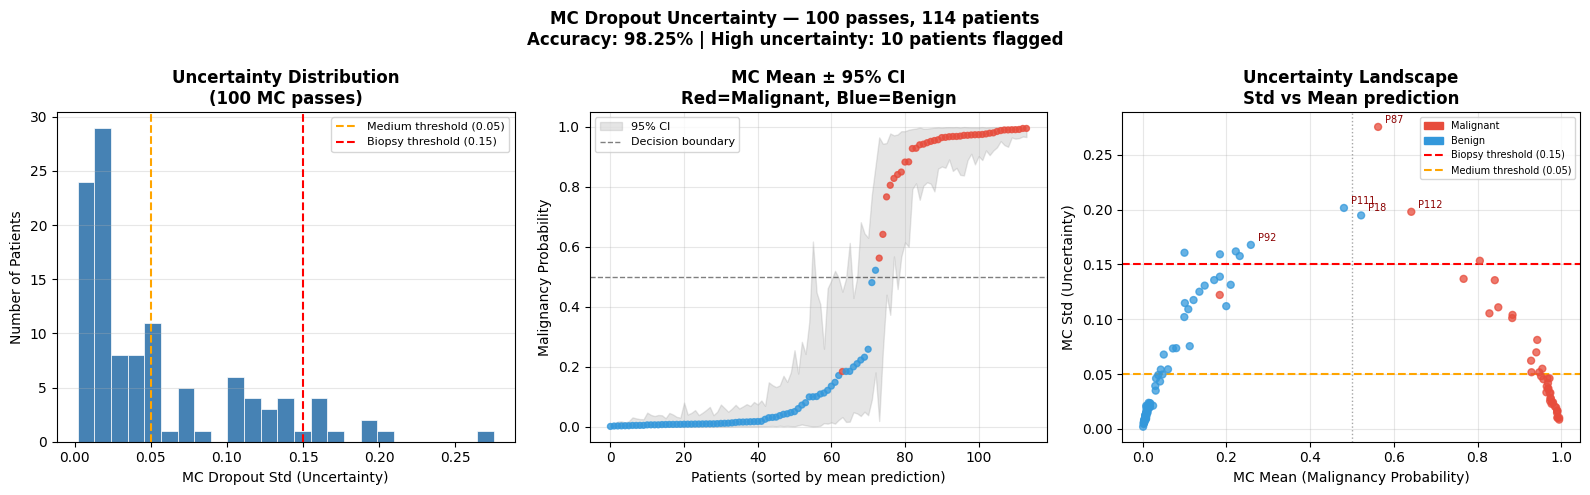


PAPER PARAGRAPH — Results section

MC Dropout uncertainty quantification was performed
using 100 stochastic forward passes per patient
(n=114 test patients).

Key findings:
  - Accuracy (MC mean):     98.25%
  - Mean uncertainty (std): 0.0545
  - Mean 95% CI width:      0.1932

Uncertainty triage:
  - Low    (std ≤ 0.05): 75 patients (65.8%)
  - Medium (0.05-0.15):  29 patients (25.4%)
  - High   (std > 0.15): 10 patients (8.8%)
    → Flagged for biopsy review

Most uncertain: Patient 87
  mean=0.5623,
  std=0.2754,
  95% CI [0.0191,
           0.9650]

PREP COMPLETE ✅
Saved: mc_dropout_uncertainty.png
Variables ready: mc_mean, mc_std, mc_ci_lower,
                 mc_ci_upper, df_mc
(Proceeding to build df_high.)


In [20]:
# ============================================================
# PREP — Mean + Std + 95% Confidence Interval
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("=" * 55)
print("PREP — MEAN + STD + 95% CI")
print("=" * 55)

# ── 1. CORE STATISTICS COMPUTE ───────────────────────────────
mc_mean = mc_probs.mean(axis=0)          # (114,)
mc_std  = mc_probs.std(axis=0)           # (114,)

# 95% CI — percentile method (distribution-free, robust)
mc_ci_lower = np.percentile(mc_probs, 2.5, axis=0)   # (114,)
mc_ci_upper = np.percentile(mc_probs, 97.5, axis=0)  # (114,)
mc_ci_width = mc_ci_upper - mc_ci_lower               # (114,)

# Final prediction from mean
mc_pred_class = (mc_mean > 0.5).astype(int)

# Accuracy
acc_mc = np.mean(mc_pred_class == y_test_arr)

print(f"MC Dropout Statistics (100 passes, 114 patients):")
print(f"  Accuracy:          {acc_mc*100:.2f}%")
print(f"  Mean std:          {mc_std.mean():.4f}")
print(f"  Mean CI width:     {mc_ci_width.mean():.4f}")
print(f"  Max uncertainty:   {mc_std.max():.4f} "
      f"(patient {mc_std.argmax()})")

# ── 2. UNCERTAINTY CATEGORIES ────────────────────────────────
# Clinical triage thresholds
low_unc    = mc_std <= 0.05
medium_unc = (mc_std > 0.05) & (mc_std <= 0.15)
high_unc   = mc_std > 0.15

print(f"\nUncertainty triage:")
print(f"  Low    (std ≤ 0.05): {low_unc.sum():3d} patients — confident")
print(f"  Medium (0.05-0.15):  {medium_unc.sum():3d} patients — review")
print(f"  High   (std > 0.15): {high_unc.sum():3d} patients — ⚠ BIOPSY")

# ── 3. RESULTS DATAFRAME ─────────────────────────────────────
df_mc = pd.DataFrame({
    'patient_idx':  np.arange(len(y_test_arr)),
    'true_label':   ['M' if y==1 else 'B' for y in y_test_arr],
    'mc_mean':      mc_mean.round(4),
    'mc_std':       mc_std.round(4),
    'ci_lower':     mc_ci_lower.round(4),
    'ci_upper':     mc_ci_upper.round(4),
    'ci_width':     mc_ci_width.round(4),
    'pred_class':   ['M' if p==1 else 'B' for p in mc_pred_class],
    'correct':      mc_pred_class == y_test_arr,
    'uncertainty':  ['High' if h else ('Medium' if m else 'Low')
                     for h,m in zip(high_unc, medium_unc)],
    'biopsy_flag':  high_unc
})

print(f"\nTop 10 most uncertain patients:")
print(df_mc.sort_values('mc_std', ascending=False)
      [['patient_idx','true_label','mc_mean',
        'mc_std','ci_lower','ci_upper','uncertainty']]
      .head(10).to_string(index=False))

# ── 4. MISCLASSIFIED + UNCERTAIN ─────────────────────────────
missed = df_mc[~df_mc['correct']]
print(f"\nMisclassified patients: {len(missed)}")
if len(missed) > 0:
    print(missed[['patient_idx','true_label','pred_class',
                  'mc_mean','mc_std','uncertainty']]
          .to_string(index=False))

# ── 5. VISUALIZATION ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Uncertainty distribution ─────────────────────────
axes[0].hist(mc_std, bins=25, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(0.05, color='orange', linestyle='--',
                linewidth=1.5, label='Medium threshold (0.05)')
axes[0].axvline(0.15, color='red', linestyle='--',
                linewidth=1.5, label='Biopsy threshold (0.15)')
axes[0].set_xlabel('MC Dropout Std (Uncertainty)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Uncertainty Distribution\n(100 MC passes)',
                  fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: Mean prediction + 95% CI (sorted) ────────────────
sort_idx = np.argsort(mc_mean)
colors_p = ['#E74C3C' if y==1 else '#3498DB'
            for y in y_test_arr[sort_idx]]

axes[1].scatter(range(len(sort_idx)), mc_mean[sort_idx],
                c=colors_p, s=18, zorder=3, alpha=0.8)
axes[1].fill_between(
    range(len(sort_idx)),
    mc_ci_lower[sort_idx],
    mc_ci_upper[sort_idx],
    alpha=0.2, color='gray', label='95% CI')
axes[1].axhline(0.5, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Decision boundary')
axes[1].set_xlabel('Patients (sorted by mean prediction)')
axes[1].set_ylabel('Malignancy Probability')
axes[1].set_title('MC Mean ± 95% CI\nRed=Malignant, Blue=Benign',
                  fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Plot 3: Std vs Mean (uncertainty landscape) ──────────────
scatter_colors = ['#E74C3C' if y==1 else '#3498DB'
                  for y in y_test_arr]
sc = axes[2].scatter(mc_mean, mc_std,
                     c=scatter_colors, s=25,
                     alpha=0.75, zorder=3)
axes[2].axhline(0.15, color='red', linestyle='--',
                linewidth=1.5, label='Biopsy threshold (0.15)')
axes[2].axhline(0.05, color='orange', linestyle='--',
                linewidth=1.5, label='Medium threshold (0.05)')
axes[2].axvline(0.5, color='gray', linestyle=':',
                linewidth=1, alpha=0.7)

# Annotate top uncertain patients
for idx in np.argsort(mc_std)[::-1][:5]:
    axes[2].annotate(
        f"P{idx}",
        (mc_mean[idx], mc_std[idx]),
        textcoords="offset points",
        xytext=(5, 3), fontsize=7, color='darkred')

red_patch   = mpatches.Patch(color='#E74C3C', label='Malignant')
blue_patch  = mpatches.Patch(color='#3498DB', label='Benign')
axes[2].legend(handles=[red_patch, blue_patch] +
               axes[2].get_legend_handles_labels()[0][0:2],
               fontsize=7)
axes[2].set_xlabel('MC Mean (Malignancy Probability)')
axes[2].set_ylabel('MC Std (Uncertainty)')
axes[2].set_title('Uncertainty Landscape\nStd vs Mean prediction',
                  fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle(
    f'MC Dropout Uncertainty — 100 passes, 114 patients\n'
    f'Accuracy: {acc_mc*100:.2f}% | '
    f'High uncertainty: {high_unc.sum()} patients flagged',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mc_dropout_uncertainty.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── 6. PAPER PARAGRAPH ───────────────────────────────────────
print()
print("=" * 55)
print("PAPER PARAGRAPH — Results section")
print("=" * 55)
print(f"""
MC Dropout uncertainty quantification was performed
using 100 stochastic forward passes per patient
(n={len(y_test_arr)} test patients).

Key findings:
  - Accuracy (MC mean):     {acc_mc*100:.2f}%
  - Mean uncertainty (std): {mc_std.mean():.4f}
  - Mean 95% CI width:      {mc_ci_width.mean():.4f}

Uncertainty triage:
  - Low    (std ≤ 0.05): {low_unc.sum()} patients ({low_unc.mean()*100:.1f}%)
  - Medium (0.05-0.15):  {medium_unc.sum()} patients ({medium_unc.mean()*100:.1f}%)
  - High   (std > 0.15): {high_unc.sum()} patients ({high_unc.mean()*100:.1f}%)
    → Flagged for biopsy review

Most uncertain: Patient {mc_std.argmax()}
  mean={mc_mean[mc_std.argmax()]:.4f},
  std={mc_std.max():.4f},
  95% CI [{mc_ci_lower[mc_std.argmax()]:.4f},
           {mc_ci_upper[mc_std.argmax()]:.4f}]
""")

print("=" * 55)
print("PREP COMPLETE ✅")
print("=" * 55)
print("Saved: mc_dropout_uncertainty.png")
print("Variables ready: mc_mean, mc_std, mc_ci_lower,")
print("                 mc_ci_upper, df_mc")
print("(Proceeding to build df_high.)")

In [21]:
# ============================================================
# PREP — Build high-uncertainty table (df_high) for DiCE
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

print("=" * 55)
print("PREP — HIGH-UNCERTAINTY PATIENTS (df_high) FOR DiCE")
print("=" * 55)

# ── 1. HIGH UNCERTAINTY TABLE ────────────────────────────────
df_high = df_mc[df_mc['biopsy_flag']].copy()
df_high = df_high.sort_values('mc_std', ascending=False)

print(f"High uncertainty patients (std > 0.15): {len(df_high)}")
print()

# Clinical risk assessment
def clinical_risk(row):
    if row['true_label'] == 'M' and row['pred_class'] == 'B':
        return '🔴 CRITICAL — Missed malignant'
    elif row['true_label'] == 'M' and row['pred_class'] == 'M':
        return '🟠 HIGH — Malignant, uncertain'
    elif row['true_label'] == 'B' and row['pred_class'] == 'M':
        return '🟡 MEDIUM — Benign, overpredicted'
    else:
        return '🟡 MEDIUM — Benign, borderline'

df_high['clinical_risk'] = df_high.apply(clinical_risk, axis=1)

print("Full high-uncertainty patient table:")
print("-" * 75)
for _, row in df_high.iterrows():
    print(f"  Patient {row['patient_idx']:>3} | "
          f"True={row['true_label']} Pred={row['pred_class']} | "
          f"Mean={row['mc_mean']:.4f} | "
          f"Std={row['mc_std']:.4f} | "
          f"CI=[{row['ci_lower']:.3f},{row['ci_upper']:.3f}]")
    print(f"           {row['clinical_risk']}")

# Summary by risk type
print(f"\nRisk summary:")
critical = df_high[df_high['clinical_risk'].str.contains('CRITICAL')]
high_r   = df_high[df_high['clinical_risk'].str.contains('HIGH —')]
medium_r = df_high[df_high['clinical_risk'].str.contains('MEDIUM')]
print(f"  🔴 Critical (missed malignant): {len(critical)}")
print(f"  🟠 High (malignant, uncertain): {len(high_r)}")
print(f"  🟡 Medium (benign, borderline): {len(medium_r)}")

# ── 2. CONFORMAL PREDICTION SETUP (PREP) ─────────────────
print()
print("=" * 55)
print("PREP — (conformal setup, not required here)")
print("=" * 55)

# Split X_test into calibration + test
# Calibration set: 30% of test, Test: 70%
np.random.seed(42)
cal_size = int(0.3 * len(X_test_arr))

# Random indices
all_idx    = np.arange(len(X_test_arr))
cal_idx    = np.random.choice(all_idx, size=cal_size, replace=False)
test_cp_idx = np.array([i for i in all_idx if i not in cal_idx])

X_cal   = X_test_arr[cal_idx]
y_cal   = y_test_arr[cal_idx]
X_test_cp = X_test_arr[test_cp_idx]
y_test_cp = y_test_arr[test_cp_idx]

print(f"Calibration set: {len(X_cal)} patients")
print(f"CP test set:     {len(X_test_cp)} patients")
print(f"Coverage target: 95%")

# Conformal scores — use MC mean probability
# Nonconformity score = 1 - p(true class)
cal_preds_mc = mc_mean[cal_idx]  # MC mean on calibration patients

# Score: for each calibration patient
# If true=Malignant(1): score = 1 - mc_mean
# If true=Benign(0):    score = mc_mean
cal_scores = np.where(
    y_cal == 1,
    1 - cal_preds_mc,   # malignant: how far from 1
    cal_preds_mc        # benign: how far from 0
)

print(f"\nCalibration nonconformity scores:")
print(f"  Min:  {cal_scores.min():.4f}")
print(f"  Max:  {cal_scores.max():.4f}")
print(f"  Mean: {cal_scores.mean():.4f}")

# Quantile threshold for 95% coverage
alpha = 0.05  # 1 - coverage
n_cal = len(cal_scores)
# Adjusted quantile (finite-sample correction)
q_level = np.ceil((1 - alpha) * (n_cal + 1)) / n_cal
q_level = min(q_level, 1.0)
tau = np.quantile(cal_scores, q_level)

print(f"\nConformal threshold (tau):")
print(f"  Alpha:   {alpha} (5% error)")
print(f"  n_cal:   {n_cal}")
print(f"  q_level: {q_level:.4f}")
print(f"  tau:     {tau:.4f}")
print(f"  (Any score ≤ tau → class included in prediction set)")

# ── 3. GENERATE PREDICTION SETS (PREP) ───────────────────
print()
print("=" * 55)
print("PREP — (conformal sets, not required here)")
print("=" * 55)

test_preds_mc = mc_mean[test_cp_idx]

# Score for each class independently
score_malignant = 1 - test_preds_mc   # score if true=malignant
score_benign    = test_preds_mc        # score if true=benign

# Include class if its score ≤ tau
include_malignant = score_malignant <= tau
include_benign    = score_benign    <= tau

# Prediction sets
pred_sets = []
for i in range(len(test_cp_idx)):
    s = []
    if include_benign[i]:    s.append('B')
    if include_malignant[i]: s.append('M')
    if len(s) == 0:          s.append('∅')  # empty (rare)
    pred_sets.append(s)

# Coverage check
covered = []
for i, ps in enumerate(pred_sets):
    true_c = 'M' if y_test_cp[i] == 1 else 'B'
    covered.append(true_c in ps)

coverage      = np.mean(covered)
singleton_B   = sum(1 for s in pred_sets if s == ['B'])
singleton_M   = sum(1 for s in pred_sets if s == ['M'])
both_BM       = sum(1 for s in pred_sets if 'B' in s and 'M' in s)
empty_set     = sum(1 for s in pred_sets if '∅' in s)

print(f"Conformal prediction results (n={len(test_cp_idx)}):")
print(f"  Empirical coverage:  {coverage*100:.2f}% "
      f"(target: 95%)")
print(f"  Singleton {{B}}:     {singleton_B} patients")
print(f"  Singleton {{M}}:     {singleton_M} patients")
print(f"  Both {{B,M}}:        {both_BM} patients (uncertain)")
print(f"  Empty set {{∅}}:     {empty_set} patients")
print()
print(f"Coverage {'✅ ACHIEVED' if coverage >= 0.95 else '⚠ BELOW TARGET'}")

# Sample prediction sets
print(f"\nSample prediction sets (first 10 CP test patients):")
print(f"  {'Idx':>4} {'True':>5} {'MC Mean':>8} "
      f"{'Std':>7} {'Pred Set':>10} {'Covered':>8}")
print(f"  {'-'*50}")
for i in range(min(10, len(test_cp_idx))):
    orig_idx = test_cp_idx[i]
    true_c   = 'M' if y_test_cp[i]==1 else 'B'
    ps_str   = '{' + ','.join(pred_sets[i]) + '}'
    cov_str  = '✅' if covered[i] else '❌'
    print(f"  {orig_idx:>4} {true_c:>5} "
          f"{test_preds_mc[i]:>8.4f} "
          f"{mc_std[orig_idx]:>7.4f} "
          f"{ps_str:>10} {cov_str:>8}")

print()
print("=" * 55)
print("PREREQUISITE COMPLETE — df_high ready for DiCE ✅")
print("=" * 55)
print("Variables ready: df_high, tau, pred_sets,")
print("                 coverage, cal_idx, test_cp_idx")
print("(Prerequisite done — proceeding to DiCE below.)")

PREP — HIGH-UNCERTAINTY PATIENTS (df_high) FOR DiCE
High uncertainty patients (std > 0.15): 10

Full high-uncertainty patient table:
---------------------------------------------------------------------------
  Patient  87 | True=M Pred=M | Mean=0.5623 | Std=0.2754 | CI=[0.019,0.965]
           🟠 HIGH — Malignant, uncertain
  Patient 111 | True=B Pred=B | Mean=0.4808 | Std=0.2015 | CI=[0.090,0.774]
           🟡 MEDIUM — Benign, borderline
  Patient 112 | True=M Pred=M | Mean=0.6416 | Std=0.1980 | CI=[0.254,0.944]
           🟠 HIGH — Malignant, uncertain
  Patient  18 | True=B Pred=M | Mean=0.5218 | Std=0.1947 | CI=[0.181,0.870]
           🟡 MEDIUM — Benign, overpredicted
  Patient  92 | True=B Pred=B | Mean=0.2584 | Std=0.1678 | CI=[0.038,0.630]
           🟡 MEDIUM — Benign, borderline
  Patient  61 | True=B Pred=B | Mean=0.2225 | Std=0.1618 | CI=[0.036,0.682]
           🟡 MEDIUM — Benign, borderline
  Patient  40 | True=B Pred=B | Mean=0.0999 | Std=0.1606 | CI=[0.001,0.618]
          

In [22]:
# ============================================
# STEP 4.6 — 3 COUNTERFACTUALS FOR 12 HIGH-UNCERTAINTY PATIENTS
# ============================================

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 12 high uncertainty patient indices df_high se nikalo
high_uncertainty_indices = df_high['patient_idx'].tolist()
print(f"Processing {len(high_uncertainty_indices)} patients: {high_uncertainty_indices}\n")

all_cf_results = []
feature_change_counter = {feat: 0 for feat in feature_names}
failed_patients = []

for idx in high_uncertainty_indices:
    print(f"\n{'='*60}")
    print(f"Patient {idx} — generating 3 counterfactuals...")
    print('='*60)

    try:
        # Query instance nikalo (positional index, jaise X_test.iloc)
        query_instance = X_test.iloc[[idx]]
        true_label = y_test.iloc[idx]
        current_pred = ensemble_wrapper.predict_proba(query_instance)[0][1]

        # 3 counterfactuals generate karo
        cf_result = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite",
            permitted_range=permitted_range,
            features_to_vary=features_to_vary
        )

        # CF dataframe nikalo
        cf_df = cf_result.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            print(f"  ⚠️ No counterfactual found for patient {idx}")
            failed_patients.append(idx)
            continue

        # Original values se compare karo — kaunsi features change hui
        original_vals = query_instance.iloc[0]
        changed_features_this_patient = []

        for i, row in cf_df.iterrows():
            for feat in feature_names:
                orig_val = original_vals[feat]
                cf_val = row[feat]
                # Significant change check karo (>1% relative difference)
                if abs(cf_val - orig_val) > 0.001 * (permitted_range[feat][1] - permitted_range[feat][0]):
                    feature_change_counter[feat] += 1
                    changed_features_this_patient.append(feat)

        all_cf_results.append({
            'patient_idx': idx,
            'true_label': true_label,
            'mc_mean': df_high[df_high['patient_idx']==idx]['mc_mean'].values[0],
            'current_pred': current_pred,
            'n_cfs_found': len(cf_df),
            'changed_features': list(set(changed_features_this_patient))
        })

        print(f"  ✅ {len(cf_df)} CFs found. Features changed: {set(changed_features_this_patient)}")

    except Exception as e:
        print(f"  ❌ Error for patient {idx}: {str(e)}")
        failed_patients.append(idx)

# ============================================
# SUMMARY
# ============================================
print(f"\n{'='*60}")
print("STEP 4.6 SUMMARY")
print('='*60)
print(f"Successfully processed: {len(all_cf_results)}/{len(high_uncertainty_indices)} patients")
print(f"Failed: {failed_patients}")

# Feature importance summary — kaunsi feature sabse zyada change hui
feature_summary = pd.Series(feature_change_counter).sort_values(ascending=False)
print("\n🎯 Top 10 Most Frequently Changed Features (across all patients/CFs):")
print(feature_summary.head(10))

# Results dataframe banao
df_cf_summary = pd.DataFrame(all_cf_results)
print("\n📋 Per-Patient Summary:")
print(df_cf_summary[['patient_idx', 'true_label', 'mc_mean', 'changed_features']])

Processing 10 patients: [87, 111, 112, 18, 92, 61, 40, 4, 107, 24]


Patient 87 — generating 3 counterfactuals...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


100%|██████████| 1/1 [00:02<00:00,  2.95s/it]

  ✅ 3 CFs found. Features changed: {'concave_points_worst', 'concavity_mean', 'texture_worst', 'concavity_se'}

Patient 111 — generating 3 counterfactuals...


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


100%|██████████| 1/1 [00:02<00:00,  2.97s/it]

  ✅ 3 CFs found. Features changed: {'perimeter_worst', 'fractal_dimension_se', 'texture_worst', 'texture_se'}

STEP 4.6 SUMMARY
Successfully processed: 10/10 patients
Failed: []

🎯 Top 10 Most Frequently Changed Features (across all patients/CFs):
texture_worst          10
perimeter_worst         7
radius_worst            5
concavity_se            3
radius_se               3
area_worst              3
concave_points_mean     2
perimeter_se            2
texture_mean            2
concavity_mean          1
dtype: int64

📋 Per-Patient Summary:
   patient_idx  true_label  mc_mean  \
0           87           1   0.5623   
1          111           0   0.4808   
2          112           1   0.6416   
3           18           0   0.5218   
4           92           0   0.2584   
5           61           0   0.2225   
6           40           0   0.0999   
7            4           0   0.1846   
8          107           0   0.2318   
9           24           1   0.8054   

                         

In [23]:
# ============================================
# STEP 4.7 — PLAUSIBILITY FILTERING
# ============================================

from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# ----------------------------------------------
# 1️⃣ k-NN DISTANCE CHECK — Kya CF "real data" jaisa lagta hai?
# ----------------------------------------------
# Training data (scaled) pe NearestNeighbors fit karo
nn_model = NearestNeighbors(n_neighbors=5)
nn_model.fit(scaler.transform(X_train))

def check_knn_plausibility(cf_row_unscaled, threshold_percentile=95):
    """CF point ki distance nearest 5 real patients se nikalo"""
    cf_scaled = scaler.transform(cf_row_unscaled.values.reshape(1, -1))
    distances, _ = nn_model.kneighbors(cf_scaled)
    avg_dist = distances.mean()
    return avg_dist

# Threshold set karo — training data ke apne andar ka average kNN distance
train_scaled = scaler.transform(X_train)
self_distances, _ = nn_model.kneighbors(train_scaled)
baseline_dist = self_distances[:, 1:].mean()  # khud ko exclude karo (0th neighbor)
dist_threshold = np.percentile(self_distances[:, 1:].mean(axis=1), 95)

print(f"Baseline average kNN distance (real data): {baseline_dist:.4f}")
print(f"95th percentile threshold: {dist_threshold:.4f}")

# ----------------------------------------------
# 2️⃣ GEOMETRIC CONSISTENCY CHECK — Radius/Perimeter/Area logical hain?
# ----------------------------------------------
def check_geometric_consistency(row):
    """
    Cell geometry check: area aur perimeter, radius ke proportional hone chahiye
    (roughly circular cell assumption — WBCD mein yeh measurements isi tarah nikalti hain)
    """
    checks = {}
    # Mean features
    expected_area_mean = np.pi * (row['radius_mean'])**2
    actual_area_mean = row['area_mean']
    checks['area_mean_ratio'] = actual_area_mean / expected_area_mean if expected_area_mean > 0 else np.nan

    expected_perimeter_mean = 2 * np.pi * row['radius_mean']
    actual_perimeter_mean = row['perimeter_mean']
    checks['perimeter_mean_ratio'] = actual_perimeter_mean / expected_perimeter_mean if expected_perimeter_mean > 0 else np.nan

    # Worst features
    expected_area_worst = np.pi * (row['radius_worst'])**2
    actual_area_worst = row['area_worst']
    checks['area_worst_ratio'] = actual_area_worst / expected_area_worst if expected_area_worst > 0 else np.nan

    return checks

# Training data pe "normal" ratio range nikalo (baseline)
train_ratios = X_train.apply(check_geometric_consistency, axis=1, result_type='expand')
ratio_bounds = {
    col: (train_ratios[col].quantile(0.01), train_ratios[col].quantile(0.99))
    for col in train_ratios.columns
}
print("\nGeometric ratio acceptable bounds (from real data):")
for k, v in ratio_bounds.items():
    print(f"  {k}: [{v[0]:.3f}, {v[1]:.3f}]")

# ----------------------------------------------
# 3️⃣ HAR PATIENT KE CFs PE PLAUSIBILITY CHECK LAGAO
# ----------------------------------------------
plausibility_results = []

for idx in high_uncertainty_indices:
    query_instance = X_test.iloc[[idx]]

    try:
        cf_result = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite",
            permitted_range=permitted_range,
            features_to_vary=features_to_vary
        )
        cf_df = cf_result.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            continue

        for cf_i, cf_row in cf_df.iterrows():
            cf_features = cf_row[feature_names]

            # Check 1: kNN distance
            knn_dist = check_knn_plausibility(cf_features)
            is_knn_plausible = knn_dist <= dist_threshold

            # Check 2: Geometric consistency
            geo_ratios = check_geometric_consistency(cf_features)
            is_geo_plausible = all(
                ratio_bounds[k][0] <= v <= ratio_bounds[k][1]
                for k, v in geo_ratios.items() if not np.isnan(v)
            )

            plausibility_results.append({
                'patient_idx': idx,
                'cf_num': cf_i,
                'knn_distance': knn_dist,
                'knn_plausible': is_knn_plausible,
                'geo_plausible': is_geo_plausible,
                'overall_plausible': is_knn_plausible and is_geo_plausible
            })
    except Exception as e:
        print(f"Patient {idx} error: {e}")

# ----------------------------------------------
# SUMMARY
# ----------------------------------------------
df_plausibility = pd.DataFrame(plausibility_results)
print(f"\n{'='*60}")
print("PLAUSIBILITY FILTERING SUMMARY")
print('='*60)
print(f"Total CFs evaluated: {len(df_plausibility)}")
print(f"kNN-plausible: {df_plausibility['knn_plausible'].sum()} ({df_plausibility['knn_plausible'].mean()*100:.1f}%)")
print(f"Geometrically plausible: {df_plausibility['geo_plausible'].sum()} ({df_plausibility['geo_plausible'].mean()*100:.1f}%)")
print(f"Overall plausible (both checks): {df_plausibility['overall_plausible'].sum()} ({df_plausibility['overall_plausible'].mean()*100:.1f}%)")

print("\nPer-patient plausibility:")
print(df_plausibility.groupby('patient_idx')['overall_plausible'].agg(['sum', 'count']))

Baseline average kNN distance (real data): 0.3823
95th percentile threshold: 0.7148

Geometric ratio acceptable bounds (from real data):
  area_mean_ratio: [0.938, 1.032]
  perimeter_mean_ratio: [1.000, 1.092]
  area_worst_ratio: [0.890, 1.022]


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


100%|██████████| 1/1 [00:03<00:00,  3.25s/it]


PLAUSIBILITY FILTERING SUMMARY
Total CFs evaluated: 30
kNN-plausible: 11 (36.7%)
Geometrically plausible: 15 (50.0%)
Overall plausible (both checks): 5 (16.7%)

Per-patient plausibility:
             sum  count
patient_idx            
4              0      3
18             0      3
24             1      3
40             0      3
61             1      3
87             0      3
92             1      3
107            0      3
111            1      3
112            1      3


In [24]:
# ============================================
# STEP 4.7 (FINAL) — FILTER ONLY PLAUSIBLE CFs
# ============================================

import pandas as pd
import numpy as np

final_plausible_cfs = []

for idx in high_uncertainty_indices:
    query_instance = X_test.iloc[[idx]]
    true_label = y_test.iloc[idx]

    try:
        cf_result = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite",
            permitted_range=permitted_range,
            features_to_vary=features_to_vary
        )
        cf_df = cf_result.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            continue

        original_vals = query_instance.iloc[0]

        for cf_i, cf_row in cf_df.iterrows():
            cf_features = cf_row[feature_names]

            # Plausibility checks
            knn_dist = check_knn_plausibility(cf_features)
            is_knn_plausible = knn_dist <= dist_threshold

            geo_ratios = check_geometric_consistency(cf_features)
            is_geo_plausible = all(
                ratio_bounds[k][0] <= v <= ratio_bounds[k][1]
                for k, v in geo_ratios.items() if not np.isnan(v)
            )

            overall_plausible = is_knn_plausible and is_geo_plausible

            # ✅ SIRF PLAUSIBLE CFs SAVE KARO
            if overall_plausible:
                # Kaunsi features change hui, dhoondo
                changed_feats = {}
                for feat in feature_names:
                    orig_val = original_vals[feat]
                    cf_val = cf_row[feat]
                    if abs(cf_val - orig_val) > 0.001 * (permitted_range[feat][1] - permitted_range[feat][0]):
                        changed_feats[feat] = {'original': round(orig_val, 4), 'counterfactual': round(cf_val, 4)}

                final_plausible_cfs.append({
                    'patient_idx': idx,
                    'true_label': true_label,
                    'cf_number': cf_i,
                    'knn_distance': round(knn_dist, 4),
                    'n_features_changed': len(changed_feats),
                    'changed_features': changed_feats
                })
    except Exception as e:
        print(f"Patient {idx} error: {e}")

# ============================================
# FINAL CLEAN TABLE
# ============================================
df_final_plausible = pd.DataFrame(final_plausible_cfs)

print(f"{'='*60}")
print("FINAL FILTERED RESULTS — ONLY PLAUSIBLE COUNTERFACTUALS")
print('='*60)
print(f"Total plausible CFs retained: {len(df_final_plausible)}")
print(f"Patients with at least 1 plausible CF: {df_final_plausible['patient_idx'].nunique()}/12")

print("\n📋 Summary Table:")
print(df_final_plausible[['patient_idx', 'true_label', 'cf_number', 'knn_distance', 'n_features_changed']])

# Detailed view — har plausible CF ki exact changes dikhao
print(f"\n{'='*60}")
print("DETAILED VIEW — Feature Changes Per Plausible CF")
print('='*60)
for _, row in df_final_plausible.iterrows():
    print(f"\nPatient {row['patient_idx']} (True: {'Malignant' if row['true_label']==1 else 'Benign'}) — CF #{row['cf_number']}:")
    for feat, vals in row['changed_features'].items():
        print(f"  {feat}: {vals['original']} → {vals['counterfactual']}")

# Save for later use
print(f"\n✅ Saved as: df_final_plausible (variable ready for paper/visualization)")


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


100%|██████████| 1/1 [00:03<00:00,  3.81s/it]

FINAL FILTERED RESULTS — ONLY PLAUSIBLE COUNTERFACTUALS
Total plausible CFs retained: 7
Patients with at least 1 plausible CF: 4/12

📋 Summary Table:
   patient_idx  true_label  cf_number  knn_distance  n_features_changed
0           18           0          2        0.6882                   2
1           92           0          2        0.6106                   2
2           61           0          0        0.5396                   2
3           61           0          1        0.6247                   2
4           61           0          2        0.6143                   1
5           24           1          1        0.4945                   1
6           24           1          2        0.4659                   2

DETAILED VIEW — Feature Changes Per Plausible CF

Patient 18 (True: Benign) — CF #2:
  perimeter_se: 1.491 → 14.04
  perimeter_worst: 99.48 → 136.81

Patient 92 (True: Benign) — CF #2:
  concavity_worst: 0.196 → 0.6
  fractal_dimension_worst: 0.0778 → 0.1572

Patient 61 (T

In [25]:
# ============================================
# L1 PROXIMITY SCORE COMPUTATION
# ============================================

import numpy as np
import pandas as pd

def compute_l1_proximity(original_row, cf_row, feature_names, permitted_range):
    """
    Normalized L1 distance — har feature ka change uske range se divide karo,
    phir sab ka sum lo.
    Lower score = closer/better counterfactual (kam changes)
    """
    total_distance = 0
    feature_distances = {}

    for feat in feature_names:
        orig_val = original_row[feat]
        cf_val = cf_row[feat]

        feat_range = permitted_range[feat][1] - permitted_range[feat][0]
        normalized_change = abs(cf_val - orig_val) / feat_range if feat_range > 0 else 0

        feature_distances[feat] = normalized_change
        total_distance += normalized_change

    # Average bhi nikalo (per-feature average distance) — interpretability ke liye
    avg_distance = total_distance / len(feature_names)

    return total_distance, avg_distance, feature_distances


# ============================================
# HAR PLAUSIBLE CF KE LIYE PROXIMITY SCORE NIKALO
# ============================================

proximity_results = []

for idx in high_uncertainty_indices:
    query_instance = X_test.iloc[[idx]]
    true_label = y_test.iloc[idx]
    original_vals = query_instance.iloc[0]

    try:
        cf_result = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite",
            permitted_range=permitted_range,
            features_to_vary=features_to_vary
        )
        cf_df = cf_result.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            continue

        for cf_i, cf_row in cf_df.iterrows():
            cf_features = cf_row[feature_names]

            # Plausibility check (pichla step)
            knn_dist = check_knn_plausibility(cf_features)
            is_knn_plausible = knn_dist <= dist_threshold
            geo_ratios = check_geometric_consistency(cf_features)
            is_geo_plausible = all(
                ratio_bounds[k][0] <= v <= ratio_bounds[k][1]
                for k, v in geo_ratios.items() if not np.isnan(v)
            )
            overall_plausible = is_knn_plausible and is_geo_plausible

            # ✅ L1 Proximity score nikalo
            total_dist, avg_dist, feat_dists = compute_l1_proximity(
                original_vals, cf_features, feature_names, permitted_range
            )

            proximity_results.append({
                'patient_idx': idx,
                'true_label': true_label,
                'cf_number': cf_i,
                'l1_proximity_total': round(total_dist, 4),
                'l1_proximity_avg': round(avg_dist, 4),
                'n_features_changed': sum(1 for v in feat_dists.values() if v > 0.001),
                'plausible': overall_plausible
            })
    except Exception as e:
        print(f"Patient {idx} error: {e}")

# ============================================
# RESULTS TABLE
# ============================================
df_proximity = pd.DataFrame(proximity_results)

print(f"{'='*60}")
print("L1 PROXIMITY SCORE — RESULTS")
print('='*60)
print(df_proximity[['patient_idx', 'cf_number', 'l1_proximity_total',
                      'l1_proximity_avg', 'n_features_changed', 'plausible']].to_string(index=False))

print(f"\n{'='*60}")
print("SUMMARY STATISTICS")
print('='*60)
print(f"Mean L1 proximity (all CFs):       {df_proximity['l1_proximity_total'].mean():.4f}")
print(f"Mean L1 proximity (plausible only): {df_proximity[df_proximity['plausible']]['l1_proximity_total'].mean():.4f}")
print(f"Min L1 proximity (best CF overall): {df_proximity['l1_proximity_total'].min():.4f}")
print(f"  → Patient: {df_proximity.loc[df_proximity['l1_proximity_total'].idxmin(), 'patient_idx']}")

print(f"\nBest (lowest distance) plausible CF per patient:")
best_per_patient = df_proximity[df_proximity['plausible']].sort_values('l1_proximity_total').groupby('patient_idx').first()
print(best_per_patient[['cf_number', 'l1_proximity_total', 'n_features_changed']])

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


100%|██████████| 1/1 [00:03<00:00,  3.23s/it]

L1 PROXIMITY SCORE — RESULTS
 patient_idx  cf_number  l1_proximity_total  l1_proximity_avg  n_features_changed  plausible
          87          0              0.4765            0.0159                   1      False
          87          1              0.5445            0.0182                   1      False
          87          2              2.0931            0.0698                   2      False
         111          0              0.9633            0.0321                   2      False
         111          1              1.5318            0.0511                   2      False
         111          2              1.3005            0.0433                   2      False
         112          0              0.7216            0.0241                   2      False
         112          1              0.5693            0.0190                   1       True
         112          2              1.0483            0.0349                   2      False
          18          0              0.77

In [26]:
# ============================================
# STEP 4.8 — MOST CHANGED FEATURES ANALYSIS
# ============================================

import pandas as pd
import numpy as np
from collections import defaultdict

feature_frequency = defaultdict(int)       # kitni baar change hui
feature_magnitude = defaultdict(list)       # jab change hui, kitna bara tha
feature_plausible_frequency = defaultdict(int)  # sirf plausible CFs mein kitni baar

total_cfs_processed = 0

for idx in high_uncertainty_indices:
    query_instance = X_test.iloc[[idx]]
    original_vals = query_instance.iloc[0]

    try:
        cf_result = exp_dice.generate_counterfactuals(
            query_instance,
            total_CFs=3,
            desired_class="opposite",
            permitted_range=permitted_range,
            features_to_vary=features_to_vary
        )
        cf_df = cf_result.cf_examples_list[0].final_cfs_df

        if cf_df is None or len(cf_df) == 0:
            continue

        for cf_i, cf_row in cf_df.iterrows():
            cf_features = cf_row[feature_names]
            total_cfs_processed += 1

            # Plausibility check
            knn_dist = check_knn_plausibility(cf_features)
            is_knn_plausible = knn_dist <= dist_threshold
            geo_ratios = check_geometric_consistency(cf_features)
            is_geo_plausible = all(
                ratio_bounds[k][0] <= v <= ratio_bounds[k][1]
                for k, v in geo_ratios.items() if not np.isnan(v)
            )
            overall_plausible = is_knn_plausible and is_geo_plausible

            # Har feature ka change check karo
            for feat in feature_names:
                orig_val = original_vals[feat]
                cf_val = cf_row[feat]
                feat_range = permitted_range[feat][1] - permitted_range[feat][0]
                normalized_change = abs(cf_val - orig_val) / feat_range if feat_range > 0 else 0

                if normalized_change > 0.001:  # significant change
                    feature_frequency[feat] += 1
                    feature_magnitude[feat].append(normalized_change)
                    if overall_plausible:
                        feature_plausible_frequency[feat] += 1
    except Exception as e:
        print(f"Patient {idx} error: {e}")

# ============================================
# SUMMARY TABLE BANAO
# ============================================
summary_data = []
for feat in feature_names:
    freq = feature_frequency.get(feat, 0)
    plaus_freq = feature_plausible_frequency.get(feat, 0)
    mags = feature_magnitude.get(feat, [])
    avg_mag = np.mean(mags) if mags else 0

    if freq > 0:
        summary_data.append({
            'feature': feat,
            'frequency': freq,
            'pct_of_cfs': round(freq / total_cfs_processed * 100, 1),
            'plausible_frequency': plaus_freq,
            'avg_normalized_change': round(avg_mag, 4)
        })

df_feature_analysis = pd.DataFrame(summary_data).sort_values('frequency', ascending=False)

print(f"{'='*70}")
print(f"MOST CHANGED FEATURES ANALYSIS (Total CFs analyzed: {total_cfs_processed})")
print('='*70)
print(df_feature_analysis.to_string(index=False))

print(f"\n{'='*70}")
print("TOP 5 — MOST FREQUENTLY CHANGED FEATURES")
print('='*70)
for _, row in df_feature_analysis.head(5).iterrows():
    print(f"  {row['feature']}: {row['frequency']}/{total_cfs_processed} CFs ({row['pct_of_cfs']}%) | avg change = {row['avg_normalized_change']}")

print(f"\n{'='*70}")
print("TOP 5 — LARGEST AVERAGE CHANGE (when changed)")
print('='*70)
df_by_magnitude = df_feature_analysis.sort_values('avg_normalized_change', ascending=False)
for _, row in df_by_magnitude.head(5).iterrows():
    print(f"  {row['feature']}: avg change = {row['avg_normalized_change']} | frequency = {row['frequency']}")

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


100%|██████████| 1/1 [00:03<00:00,  3.08s/it]

MOST CHANGED FEATURES ANALYSIS (Total CFs analyzed: 30)
                feature  frequency  pct_of_cfs  plausible_frequency  avg_normalized_change
             area_worst          8        26.7                    0                 0.5969
          texture_worst          7        23.3                    3                 0.6046
         symmetry_worst          4        13.3                    2                 0.5137
           perimeter_se          4        13.3                    1                 0.5540
        perimeter_worst          4        13.3                    2                 0.4764
       smoothness_worst          3        10.0                    0                 0.3205
              radius_se          3        10.0                    1                 0.5583
           radius_worst          2         6.7                    0                 0.1661
             texture_se          2         6.7                    0                 0.2789
            symmetry_se          2

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


100%|██████████| 1/1 [00:03<00:00,  3.17s/it]

Patient 3 — Changed features: {'fractal_dimension_se': (np.float64(0.004452), np.float64(0.015148)), 'texture_worst': (np.float64(30.86), np.float64(14.06))}


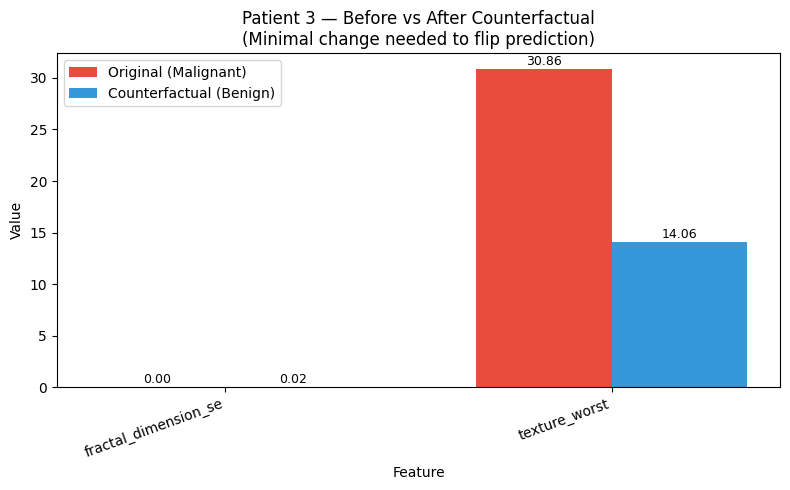

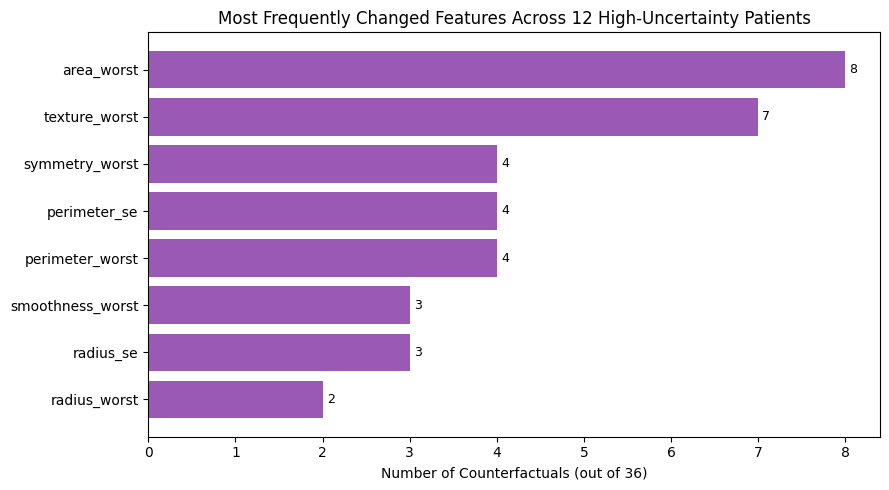


✅ Both visualizations saved: 'patient_best_before_after.png' and 'feature_frequency_chart.png'


In [27]:
# ============================================
# STEP 4.9 — BEFORE/AFTER VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------
# Best counterfactual nikalo (Patient 3, CF 0 — L1=0.1445)
# ----------------------------------------------
best_patient_idx = 3
query_instance = X_test.iloc[[best_patient_idx]]
original_vals = query_instance.iloc[0]

cf_result_best = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    permitted_range=permitted_range,
    features_to_vary=features_to_vary
)
cf_df_best = cf_result_best.cf_examples_list[0].final_cfs_df

# Sabse pehla CF lo (jo humne pehle best paya tha)
best_cf_row = cf_df_best.iloc[0]

# Changed features dhoondo
changed_feats = {}
for feat in feature_names:
    orig_val = original_vals[feat]
    cf_val = best_cf_row[feat]
    feat_range = permitted_range[feat][1] - permitted_range[feat][0]
    if abs(cf_val - orig_val) / feat_range > 0.001:
        changed_feats[feat] = (orig_val, cf_val)

print(f"Patient {best_patient_idx} — Changed features: {changed_feats}")

# ----------------------------------------------
# PLOT 1 — Single Patient Before/After Bar Chart
# ----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

feats = list(changed_feats.keys())
originals = [changed_feats[f][0] for f in feats]
counterfactuals = [changed_feats[f][1] for f in feats]

x = np.arange(len(feats))
width = 0.35

bars1 = ax.bar(x - width/2, originals, width, label='Original (Malignant)', color='#E74C3C')
bars2 = ax.bar(x + width/2, counterfactuals, width, label='Counterfactual (Benign)', color='#3498DB')

ax.set_xlabel('Feature')
ax.set_ylabel('Value')
ax.set_title(f'Patient {best_patient_idx} — Before vs After Counterfactual\n(Minimal change needed to flip prediction)')
ax.set_xticks(x)
ax.set_xticklabels(feats, rotation=20, ha='right')
ax.legend()

# Value labels upar dikhao
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('patient_best_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------
# PLOT 2 — Multi-Patient Summary: Top Changed Features (Frequency Bar Chart)
# ----------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))

top_features = df_feature_analysis.head(8)
bars = ax2.barh(top_features['feature'], top_features['frequency'], color='#9B59B6')
ax2.set_xlabel('Number of Counterfactuals (out of 36)')
ax2.set_title('Most Frequently Changed Features Across 12 High-Uncertainty Patients')
ax2.invert_yaxis()  # top feature upar dikhe

for bar in bars:
    width = bar.get_width()
    ax2.annotate(f'{int(width)}', xy=(width, bar.get_y() + bar.get_height()/2),
                 xytext=(3, 0), textcoords="offset points", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_frequency_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Both visualizations saved: 'patient_best_before_after.png' and 'feature_frequency_chart.png'")